### references 
- https://www.youtube.com/watch?v=N-49t1j-XWY 
- https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

### Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
import time
import seaborn as sns
import os
from data_cleaning_class import DataCleaner
from data_explorer_class import DataExplorer
import re
pd.set_option('display.max_rows', None)

### Loading

In [2]:
script_dir = os.getcwd()
csv_path = os.path.join(script_dir , "kl.csv")
print(csv_path)

decoded_df = pd.read_csv(csv_path , encoding="cp1252")


/home/youssef/mia_ai/Task_2/Task2.2/kl.csv


### Data Exploring

=== STATISTICS ===
         Unnamed: 0             ID           Age       Overall     Potential  \
count  18207.000000   18207.000000  18206.000000  18206.000000  18207.000000   
mean    9103.000000  214298.338606     25.122048     66.237449     71.307299   
std     5256.052511   29965.244204      4.670022      6.907059      6.136496   
min        0.000000      16.000000     16.000000     46.000000     48.000000   
25%     4551.500000  200315.500000     21.000000     62.000000     67.000000   
50%     9103.000000  221759.000000     25.000000     66.000000     71.000000   
75%    13654.500000  236529.500000     28.000000     71.000000     75.000000   
99%    18023.940000  246089.940000     36.000000     83.000000     87.000000   
max    18206.000000  246620.000000     45.000000     94.000000     95.000000   

            Special  International Reputation     Weak Foot   Skill Moves  \
count  18207.000000              18159.000000  18159.000000  18159.000000   
mean    1597.809908       

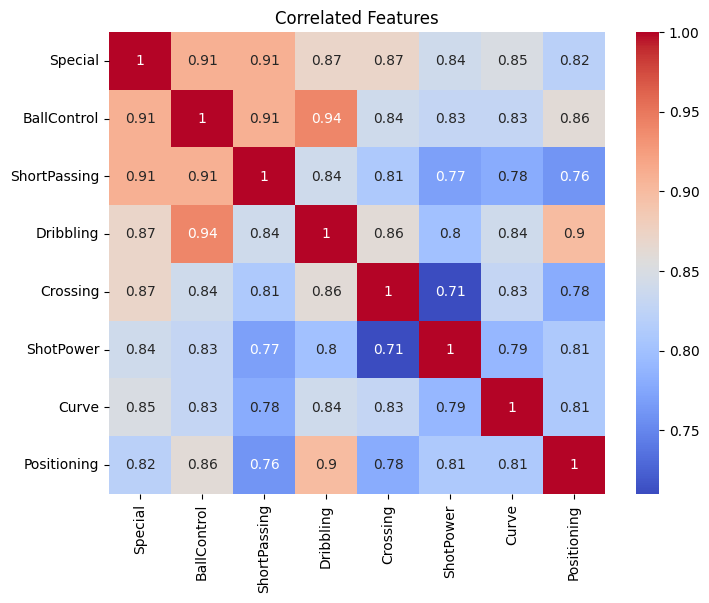

In [3]:
data_explorer = DataExplorer(csv_path) 
data_explorer.values_inspection()       #think i'll modify the class in the feature to exclude things like ID,unnamed,jersy number o.o
data_explorer.basic_structure()         #88 feature that's very high dimension relative to only 18207 sample
data_explorer.check_for_skewness()      # 
data_explorer.check_outliers()
data_explorer.get_duplicates()
data_explorer.get_correlations()        #some are very highly correlated , making them suitable for PCA
#i guess nationally can be important,since for example brazilians seems to be "talented", will look for a way to turn them into numerics for PCA , currently i'm thinking of a simple directory
#salary values should be stripped of € and turned into numerical while replacing k with 10^^3,..etc
#preferred foot can be mapped to [0,1]
# according to google Work Rate in FIFA is a two-part rating showing how actively a player moves without the ball
# i guess that's kinda important for defender so i'll map it too 
# others are already numerical so i'll keep them , i'll let the AI decide about those weird letters ones, but i'll keep as many as possible because i wanna see how PCA will determine most important factors


### Creating Numerical Dataset

In [4]:
drop_cols = ['Unnamed: 0', 'ID']
players_df = decoded_df.drop(columns=drop_cols)

position_cols = ['LS','ST','RS','LW','LF','CF','RF','RW','LAM','CAM','RAM','LM',
                  'LCM','CM','RCM','RM','LWB','LDM','CDM','RDM','RWB','LB','LCB',
                  'CB','RCB','RB']

for col in position_cols :
    players_df[col] = players_df[col].str.split("+" , expand= True).astype(float).sum(axis= 1)

# print (players_df[["LS" , "ST"]].head(10))

currency_cols = ['Value', 'Wage', 'Release Clause']
def parse_currency(val):
    val = str(val).replace('€', '').strip()
    multiplier = 1
    
    if val.endswith('M'):
        multiplier = 1_000_000
        val = val[:-1]
    elif val.endswith('K'):
        multiplier = 1_000
        val = val[:-1]
    try:
        return float(val) * multiplier
    except ValueError:
        return np.nan

for col in currency_cols:
    players_df[col] = players_df[col].apply(parse_currency)


# print(players_df[currency_cols].head(5))

def parse_height(val):
    if pd.isna(val):
        return np.nan

    val= str(val).split("'")
    val = [float(value) for value in val]
    val_inch = val[0] * 12 + val[1]
    val_cm   = val_inch * 2.54           #guess it doesn't matter since normalization is done anyway

    return float(val_cm)

players_df["Height"] =players_df["Height"].apply(parse_height)


def parse_weight(val) :
    if pd.isna(val) :
        return np.nan

    val = val.strip("lbs")
    return float(val)

players_df["Weight"] = players_df["Weight"].apply(parse_weight)

print(players_df['Preferred Foot'].value_counts()) #to make sure there is someone who doesn't prefer a special leg

players_df["Preferred Foot"] = (
    players_df["Preferred Foot"].str.strip() == "Left"
).astype(int)

players_df = players_df.select_dtypes(include = 'number')




Preferred Foot
Right    13948
Left      4211
Name: count, dtype: int64


### Cleaning

In [5]:
players_df = DataCleaner(players_df).clean_df()

### numpy Implementation


#### cov matrix

In [6]:
start = time.time()
standardized_df = ((players_df - players_df.mean()) / players_df.std())
cov_matrix = np.cov(standardized_df, rowvar = False)

# cov_df = pd.DataFrame(cov_matrix, index=standardized_df.columns, columns=standardized_df.columns)

# # Rank features by total absolute covariance with all others
# cov_magnitude = cov_df.abs()
# np.fill_diagonal(cov_magnitude.values, 0)
# scores = cov_magnitude.sum().sort_values(ascending=False)

# top_features = scores.head(20).index
# top_cov = cov_df.loc[top_features, top_features]

# plt.figure(figsize=(10, 8))
# sns.heatmap(top_cov, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# plt.title('Top 20 Feature Covariance Matrix')
# plt.tight_layout()
# plt.show()

#### Eigen-Decomposition

In [7]:
eigen_values , eigen_vectors = np.linalg.eigh(cov_matrix)

#sort descending
eigenvalues = eigen_values[::-1]
eigenvectors = eigen_vectors[:, ::-1]

#### PCA -2 

 numpy arrays took : 114.70508575439453 ms
0.6792092467932531


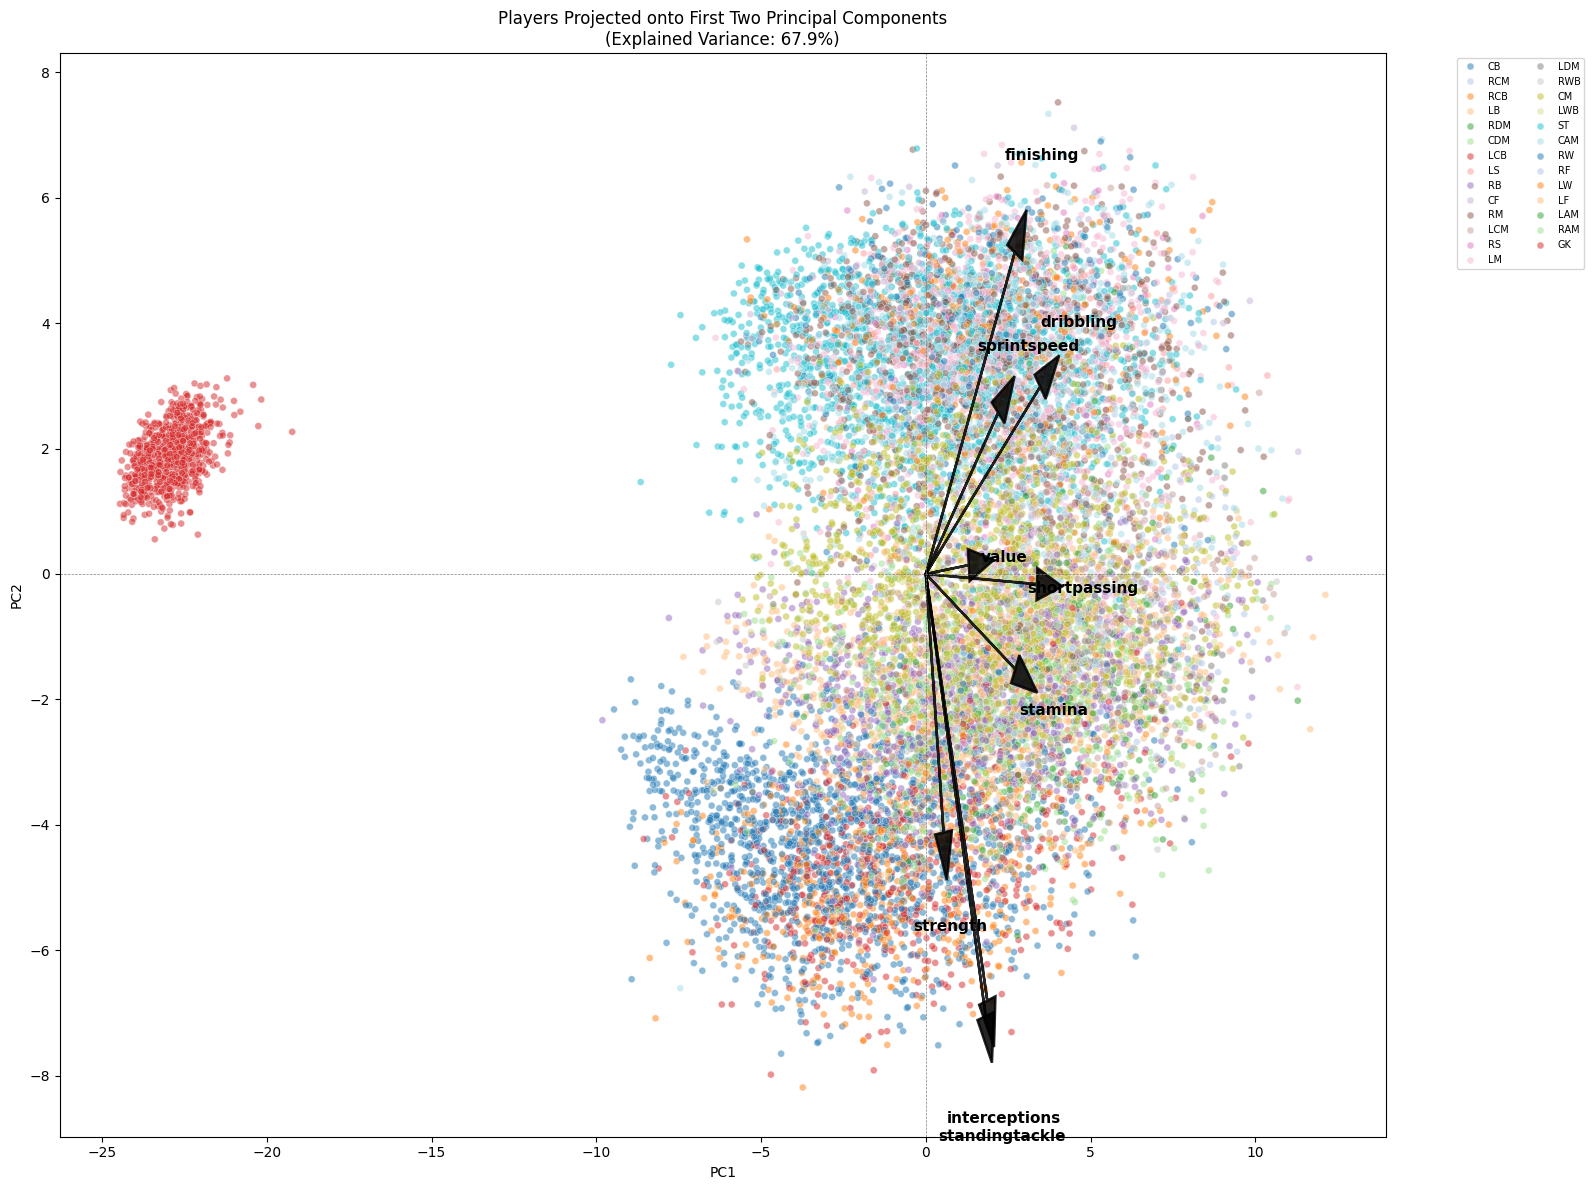

In [8]:
projection_matrix = eigenvectors[:, :2]
projected_data = standardized_df.values @ projection_matrix

pc_df = pd.DataFrame(projected_data[:, :2], columns=['PC1', 'PC2'], index=standardized_df.index)
time_required = time.time() - start 
print(f" numpy arrays took : {time_required * 1000} ms") #78.83 ms

pc_df['Position'] = decoded_df.loc[standardized_df.index, 'Position']

explained_variance_ratio = eigenvalues[:2] / eigenvalues.sum()


print(explained_variance_ratio.sum()) #0.68 explained  variance


# Visualisation 
plt.figure(figsize=(16, 12))

sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='Position', palette='tab20', s=25, alpha=0.5)

recommended_features = ['finishing', 'shortpassing', 'dribbling', 'sprintspeed',
                         'strength', 'stamina', 'interceptions', 'standingtackle', 'value']

feature_indices = [standardized_df.columns.get_loc(f) for f in recommended_features]

loadings_pc1 = eigenvectors[feature_indices, 0]
loadings_pc2 = eigenvectors[feature_indices, 1]
magnitudes = np.sqrt(loadings_pc1**2 + loadings_pc2**2)

data_range = max(pc_df['PC1'].max() - pc_df['PC1'].min(),
                  pc_df['PC2'].max() - pc_df['PC2'].min())

# Real loadings scaled to a single consistent factor - no artificial compression
scale = data_range * 0.22 / magnitudes.max()
xs = loadings_pc1 * scale
ys = loadings_pc2 * scale

texts = []
for feature, x, y in zip(recommended_features, xs, ys):
    plt.arrow(0, 0, x, y, color='black', alpha=0.85, linewidth=1.8,
              head_width=data_range * 0.014, length_includes_head=True)
    texts.append(plt.text(x * 1.15, y * 1.15, feature, color='black',
                           fontsize=11, fontweight='bold', ha='center', va='center'))

plt.title(f'Players Projected onto First Two Principal Components\n(Explained Variance: {explained_variance_ratio.sum():.1%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


#### PCA -3

In [9]:
# i made AI write this part completely for my curiosity 

projection_matrix = eigenvectors[:, :3]
projected_data = standardized_df.values @ projection_matrix

pc_df = pd.DataFrame(projected_data, columns=['PC1', 'PC2', 'PC3'], index=standardized_df.index)
pc_df['Position'] = decoded_df.loc[standardized_df.index, 'Position']

position_groups = {
    'GK': ['GK'],
    'DEF': ['LB','LCB','CB','RCB','RB','LWB','RWB'],
    'MID': ['LDM','CDM','RDM','LM','LCM','CM','RCM','RM','LAM','CAM','RAM'],
    'ATTACK': ['LW','RW','LF','CF','RF','LS','ST','RS']
}

def map_position_group(pos):
    for group, positions in position_groups.items():
        if pos in positions:
            return group
    return 'Other'

pc_df['Position_Group'] = pc_df['Position'].apply(map_position_group)

explained_variance_ratio = eigenvalues[:3] / eigenvalues.sum()
print(explained_variance_ratio.sum())




# VISUALS 
fig = px.scatter_3d(
    pc_df, x='PC1', y='PC2', z='PC3',
    color='Position_Group',
    category_orders={'Position_Group': ['GK', 'DEF', 'MID', 'ATTACK']},
    color_discrete_map={'GK': 'red', 'DEF': 'blue', 'MID': 'green', 'ATTACK': 'orange'},
    opacity=0.4,
    title='First Three Principal Components (Grouped by Role) + Feature Vectors'
)
fig.update_traces(marker=dict(size=3), selector=dict(mode='markers'))

# --- Feature vectors for the 9 recommended features ---
feature_indices = [standardized_df.columns.get_loc(f) for f in recommended_features]

loadings_pc1 = eigenvectors[feature_indices, 0]
loadings_pc2 = eigenvectors[feature_indices, 1]
loadings_pc3 = eigenvectors[feature_indices, 2]

# Scale vectors relative to the actual 3D data spread
data_range = max(
    pc_df['PC1'].max() - pc_df['PC1'].min(),
    pc_df['PC2'].max() - pc_df['PC2'].min(),
    pc_df['PC3'].max() - pc_df['PC3'].min()
)
scale = data_range * 0.4

for feature, x, y, z in zip(recommended_features, loadings_pc1, loadings_pc2, loadings_pc3):
    x_end, y_end, z_end = x * scale, y * scale, z * scale

    fig.add_trace(go.Scatter3d(
        x=[0, x_end], y=[0, y_end], z=[0, z_end],
        mode='lines+text',
        line=dict(color='red', width=12),
        text=['', feature],
        textposition='top center',
        textfont=dict(size=18, color='black'),
        showlegend=False
    ))

fig.update_layout(width=1000, height=800, legend=dict(itemsizing='constant'))
fig.show()

# makes  sense that GK are far away from the rest

0.7481015143018758


### Pure python

In [10]:
import numpy as np

class PCA_Python():
    def __init__(self , X : list[list] , n : int):
        self.X = X
        self.n = n
        self._standardize()
        self.__transpose()
        self.__covariance_matrix()

    #https://www.geeksforgeeks.org/python/transpose-matrix-single-line-python/
    #https://medium.com/@cristianleo120/principal-component-analysis-pca-from-scratch-in-python-65998c681bc0

    def _standardize(self):
        n_rows = len(self.X)
        n_cols = len(self.X[0])

        self.means = []
        self.stds = []

        for col in range(n_cols):
            col_values = [self.X[row][col] for row in range(n_rows)]
            mean = sum(col_values) / n_rows
            variance = sum((v - mean) ** 2 for v in col_values) / (n_rows - 1)
            std = variance ** 0.5
            self.means.append(mean)
            self.stds.append(std)

        self.X = [
            [(self.X[row][col] - self.means[col]) / self.stds[col] for col in range(n_cols)]
            for row in range(n_rows)
        ]


    def __transpose(self):
        self.X_transposed = [list(row) for row in zip(*self.X)]

    def __dot_product(self , A , B):
        result = [[0 for _ in range(len(B[0]))] for _ in range(len(A))]

        for i in range(len(A)):        
            for j in range(len(B[0])): 
                for k in range(len(B)):  
                    result[i][j] += A[i][k] * B[k][j]

        return result

    

    def __covariance_matrix(self):
        n = len(self.X)
        dot_product = self.__dot_product(self.X_transposed , self.X)
        self.cov_matrix = [[val / (n - 1) for val in row] for row in dot_product]

    def __fit(self , n = 2) :
        eigenvalues, eigenvectors = np.linalg.eigh(np.array(self.cov_matrix))

        self.eigenvalues = eigenvalues[::-1]
        self.eigenvectors = eigenvectors[:, ::-1]
        self.projection_matrix = self.eigenvectors[:, :n].tolist()

    def get_PCA(self) :
        self.__fit(self.n)
        projected = self.__dot_product(self.X , self.projection_matrix)
        return projected

 PCA took : 9139.437913894653 ms
0.6792092467932509


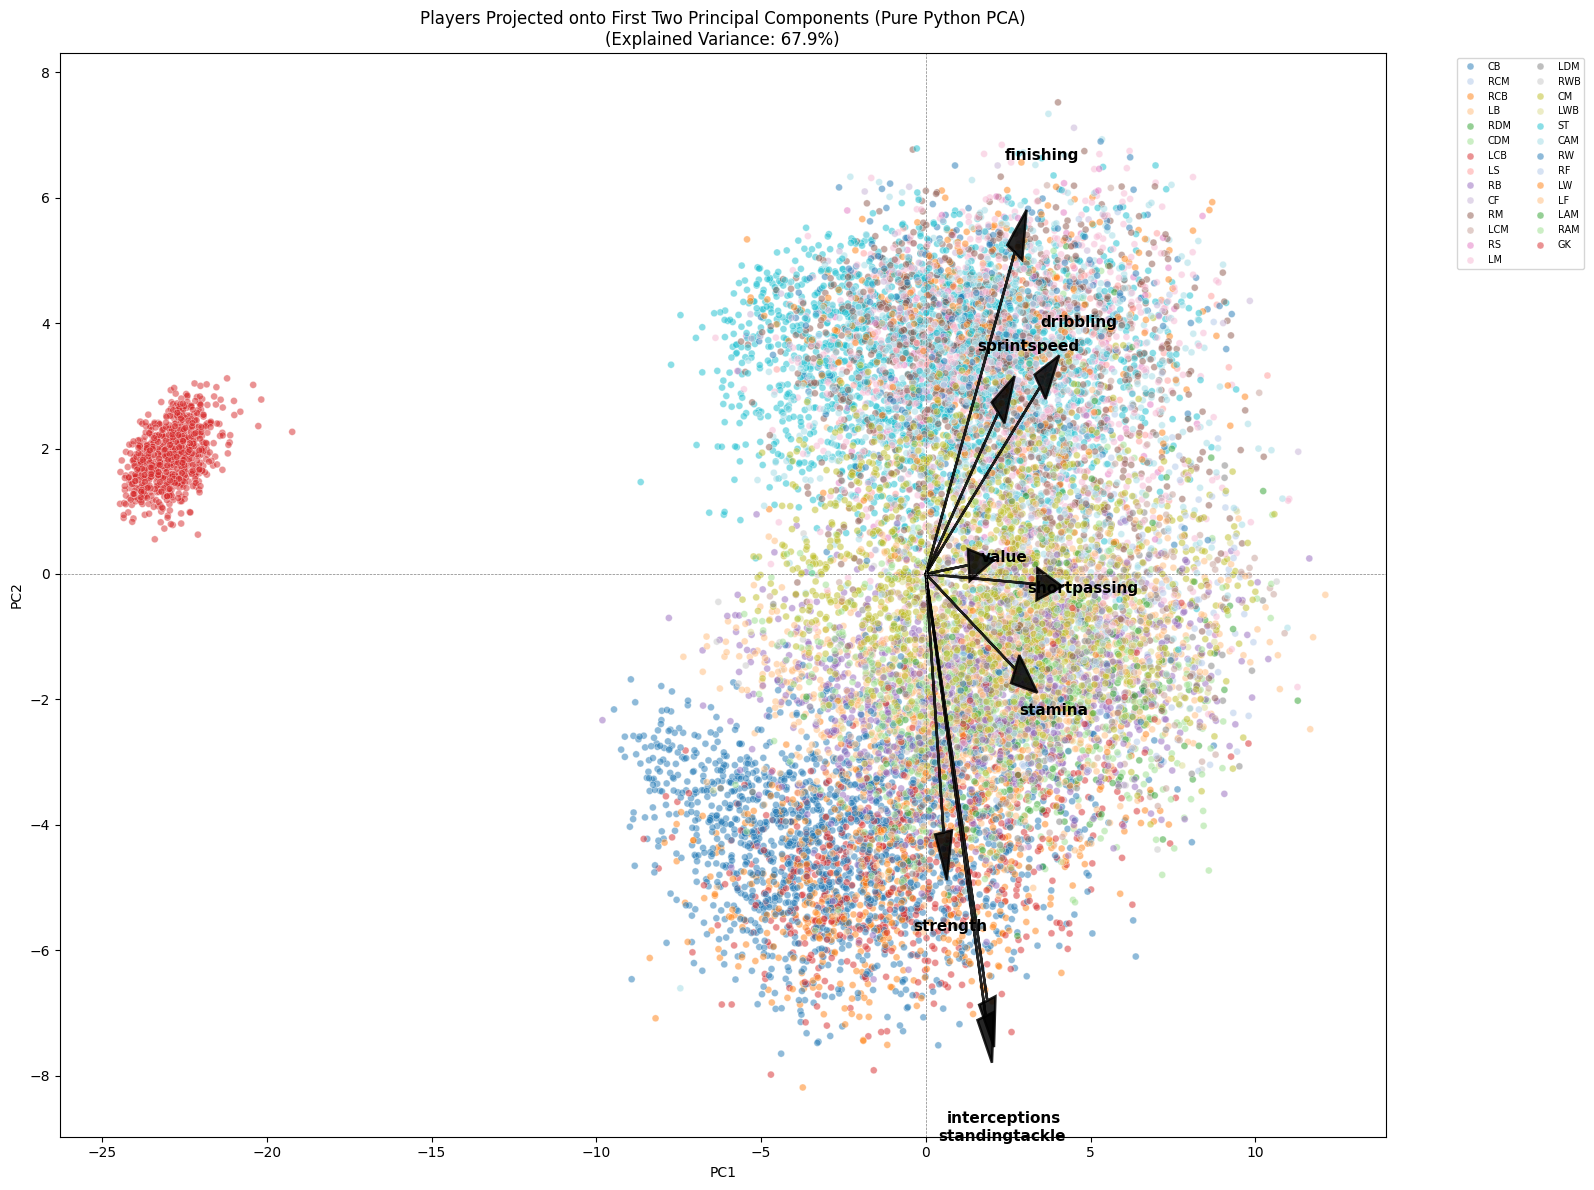

In [11]:
X_list = players_df.values.tolist()

start = time.time()
pca_manual = PCA_Python(X_list, n=2)
projected_data = np.array(pca_manual.get_PCA())  
time_required = time.time() - start
print(f" PCA took : {time_required * 1000} ms")  #8373.69 ms , almost x115 of numpy's time 

pc_df = pd.DataFrame(projected_data, columns=['PC1', 'PC2'], index=players_df.index)
pc_df['Position'] = decoded_df.loc[players_df.index, 'Position']


# Explained variance now comes from pca_manual's own eigendecomposition
explained_variance_ratio = pca_manual.eigenvalues[:2] / pca_manual.eigenvalues.sum()
print(explained_variance_ratio.sum())

# --- Visualisation ---
plt.figure(figsize=(16, 12))

sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='Position', palette='tab20', s=25, alpha=0.5)

recommended_features = ['finishing', 'shortpassing', 'dribbling', 'sprintspeed',
                         'strength', 'stamina', 'interceptions', 'standingtackle', 'value']

# Column order in pca_df should match your recommended_features order —
# confirm this, since PCA_Python has no column names, just positional indices
feature_indices = [players_df.columns.get_loc(f) for f in recommended_features]

loadings_pc1 = pca_manual.eigenvectors[feature_indices, 0]
loadings_pc2 = pca_manual.eigenvectors[feature_indices, 1]
magnitudes = np.sqrt(loadings_pc1**2 + loadings_pc2**2)

data_range = max(pc_df['PC1'].max() - pc_df['PC1'].min(),
                  pc_df['PC2'].max() - pc_df['PC2'].min())

scale = data_range * 0.22 / magnitudes.max()
xs = loadings_pc1 * scale
ys = loadings_pc2 * scale

texts = []
for feature, x, y in zip(recommended_features, xs, ys):
    plt.arrow(0, 0, x, y, color='black', alpha=0.85, linewidth=1.8,
              head_width=data_range * 0.014, length_includes_head=True)
    texts.append(plt.text(x * 1.15, y * 1.15, feature, color='black',
                           fontsize=11, fontweight='bold', ha='center', va='center'))

plt.title(f'Players Projected onto First Two Principal Components (Pure Python PCA)\n(Explained Variance: {explained_variance_ratio.sum():.1%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()